# Notebook 29b — Deterministic Identifiability Scan: (α, η_col) Retraction, (α, β_r) Confirmation

## Purpose

This notebook formalises the deterministic-simulator identifiability-scan methodology
(`scripts/identifiability_scan.py`, introduced 2026-07-03) that produced two of this
session's central findings (see HANDOFF.md Findings 8–9):

1. **Retracts** the original (α, η_col) "banana" headline at scenario W12 — it was an
   artifact of restricting the comparison to F_R-derived summary features alone; combining
   F_R with T_reb (both standard S-B channels) collapses the apparent ridge.
2. **Confirms** the plant's real, robust banana is (α, β_r) at scenario W11 — this
   degeneracy survives combination of the full S-B feature set, unlike (α, η_col).

**Methodology:** for a fixed "truth" θ and a grid over two of its components, compute the
deterministic (noise-free) summary vector at every grid point and compare it to the truth's
summary vector, normalised by the per-feature training-bank std. A restricted feature subset
that shows an extended low-distance ridge indicates that subset alone cannot distinguish
points along the ridge from the truth — a genuine degeneracy *for that subset*. Whether the
degeneracy is *real* (persists under the full available instrumentation) or a *restricted-view
artifact* (resolved once other already-available channels are included) is exactly the
question this scan answers, and exactly the distinction marginal SBC cannot make (see
Assessment).

In [1]:
import sys; sys.path.insert(0, '../scripts')
import pathlib
import numpy as np
import matplotlib.pyplot as plt

from identifiability_scan import run_scan

FIGURES = pathlib.Path('../figures'); FIGURES.mkdir(exist_ok=True)
print("Imports OK")

Imports OK


---

## Section 1 — (α, η_col) at W12: the retracted banana

W12 truth: α=0.75, η_col=0.80 (β_r, ξ_reb, z_A0 at nominal). We compare three feature
subsets: F_R-only (the restricted view that originally motivated the banana claim),
T_reb-only (a different single-channel view), and the combined 26-feature robust subset
(all available S-B channels).

In [2]:
truth_w12 = np.array([0.75, 1.0, 0.80, 1.0, 0.90], dtype=np.float32)
grid1 = (0.55, 1.15, 27)
grid2 = (0.55, 0.98, 27)

g1_fr, g2_fr, dist_fr = run_scan("alpha", "eta_col", truth_w12, grid1, grid2,
                                  channel_subset_name="F_R_norm")
g1_tr, g2_tr, dist_treb = run_scan("alpha", "eta_col", truth_w12, grid1, grid2,
                                    channel_subset_name="T_reb")
g1_c, g2_c, dist_comb = run_scan("alpha", "eta_col", truth_w12, grid1, grid2,
                                  channel_subset_name="robust")

Using 6 features (F_R_norm): ['F_R_norm_mean', 'F_R_norm_std', 'F_R_norm_slope', 'F_R_norm_min', 'F_R_norm_max', 'F_R_norm_q_mean']



alpha\eta_col distance grid (F_R_norm features):
          0.55 0.57 0.58 0.60 0.62 0.63 0.65 0.67 0.68 0.70 0.72 0.73 0.75 0.77 0.78 0.80 0.81 0.83 0.85 0.86 0.88 0.90 0.91 0.93 0.95 0.96 0.98
0.550      0.9  1.0  1.1  1.1  1.2  1.3  1.3  1.4  1.4  1.5  1.6  1.6  1.7  1.7  1.8  1.8  1.8  1.9  1.9  1.9  1.9  2.0  2.0  2.0  2.0  2.1  2.1
0.573      0.7  0.8  0.9  0.9  1.0  1.1  1.1  1.2  1.2  1.3  1.4  1.4  1.4  1.5  1.5  1.6  1.6  1.7  1.7  1.7  1.7  1.8  1.8  1.8  1.8  1.8  1.9
0.596      0.5  0.6  0.7  0.7  0.8  0.8  0.9  1.0  1.0  1.1  1.1  1.2  1.2  1.3  1.3  1.4  1.4  1.4  2.3  1.5  1.5  1.6  1.6  1.6  1.6  1.6  1.7
0.619      0.3  0.4  0.4  0.5  0.6  0.6  0.7  0.8  0.8  0.9  0.9  1.0  1.0  1.1  1.1  1.2  1.2  1.2  1.3  1.3  1.3  1.3  1.4  1.4  1.4  1.4  1.5
0.642      0.1  0.2  0.2  0.3  0.4  0.4  1.3  0.6  0.6  0.7  0.7  0.8  0.8  0.9  0.9  1.0  1.0  1.0  1.1  1.1  1.1  1.2  1.2  1.2  1.2  1.2  1.3
0.665      0.1  0.1  0.0  0.1  0.2  0.2  0.3  0.3  0.4  0.4  0.5  0.6  0.6  0.6 


alpha\eta_col distance grid (T_reb features):
          0.55 0.57 0.58 0.60 0.62 0.63 0.65 0.67 0.68 0.70 0.72 0.73 0.75 0.77 0.78 0.80 0.81 0.83 0.85 0.86 0.88 0.90 0.91 0.93 0.95 0.96 0.98
0.550      5.0  4.7  4.5  4.3  4.1  3.9  3.7  3.6  3.4  3.3  3.2  3.1  3.1  3.1  3.1  3.0  3.1  3.1  3.1  3.1  3.2  3.1  3.0  3.0  2.9  2.9  2.8
0.573      4.8  4.5  4.3  4.0  3.8  3.6  3.5  3.3  3.1  3.0  2.9  2.8  2.7  2.7  2.7  2.7  2.7  2.8  2.8  2.8  2.9  2.7  2.7  2.6  2.6  2.5  2.4
0.596      4.6  4.3  4.1  3.9  3.6  3.4  3.2  3.0  2.8  2.7  2.6  2.5  2.4  2.4  2.3  2.4  2.4  2.4  3.8  2.5  2.6  2.4  2.4  2.3  2.2  2.2  2.1
0.619      4.4  4.2  3.9  3.7  3.4  3.2  3.0  2.8  2.6  2.4  2.3  2.2  2.1  2.0  2.0  2.0  2.1  2.1  2.2  2.1  2.1  2.0  2.0  1.9  1.8  1.8  1.7
0.642      4.3  4.0  3.8  3.5  3.2  3.0  3.7  2.5  2.4  2.2  2.0  1.9  1.8  1.7  1.7  1.7  1.7  1.8  1.8  1.8  2.0  1.7  1.6  1.5  1.5  1.4  1.3
0.665      4.3  3.9  3.7  3.4  3.1  2.8  2.6  2.3  2.1  1.9  1.8  1.6  1.4  1.4  1.


alpha\eta_col distance grid (robust features):
          0.55 0.57 0.58 0.60 0.62 0.63 0.65 0.67 0.68 0.70 0.72 0.73 0.75 0.77 0.78 0.80 0.81 0.83 0.85 0.86 0.88 0.90 0.91 0.93 0.95 0.96 0.98
0.550      3.9  3.8  4.8  3.4  3.3  3.2  3.0  2.9  3.7  2.7  2.7  2.5  2.4  2.3  2.3  2.2  2.2  2.2  2.1  2.1  2.1  3.9  2.1  2.1  2.1  2.1  2.1
0.573      5.1  4.3  3.4  3.2  3.1  2.9  2.8  2.7  2.6  2.4  2.3  2.2  3.9  2.1  2.0  2.0  1.9  1.9  1.9  3.6  1.8  1.8  1.8  1.8  1.8  1.9  1.9
0.596      4.6  3.4  3.2  3.0  2.9  2.7  2.5  2.4  3.9  2.2  2.1  2.0  1.9  3.1  3.4  1.7  1.6  1.6  4.1  1.5  1.6  1.6  1.6  1.6  1.6  1.7  1.7
0.619      4.3  3.2  3.0  2.8  2.7  4.0  2.4  2.2  2.1  3.9  1.8  1.7  1.7  1.5  1.5  1.4  1.4  1.3  1.3  3.4  1.3  3.2  1.3  1.4  2.9  1.4  1.5
0.642      3.3  3.1  2.9  2.7  2.5  2.4  3.1  2.0  1.9  1.7  1.6  1.5  1.4  1.3  1.2  1.2  1.1  1.1  1.0  1.1  1.0  1.1  1.1  2.7  1.2  1.3  1.4
0.665      3.1  4.2  2.7  2.5  2.4  2.2  3.2  1.8  1.7  3.0  1.4  1.3  3.4  3.1  0

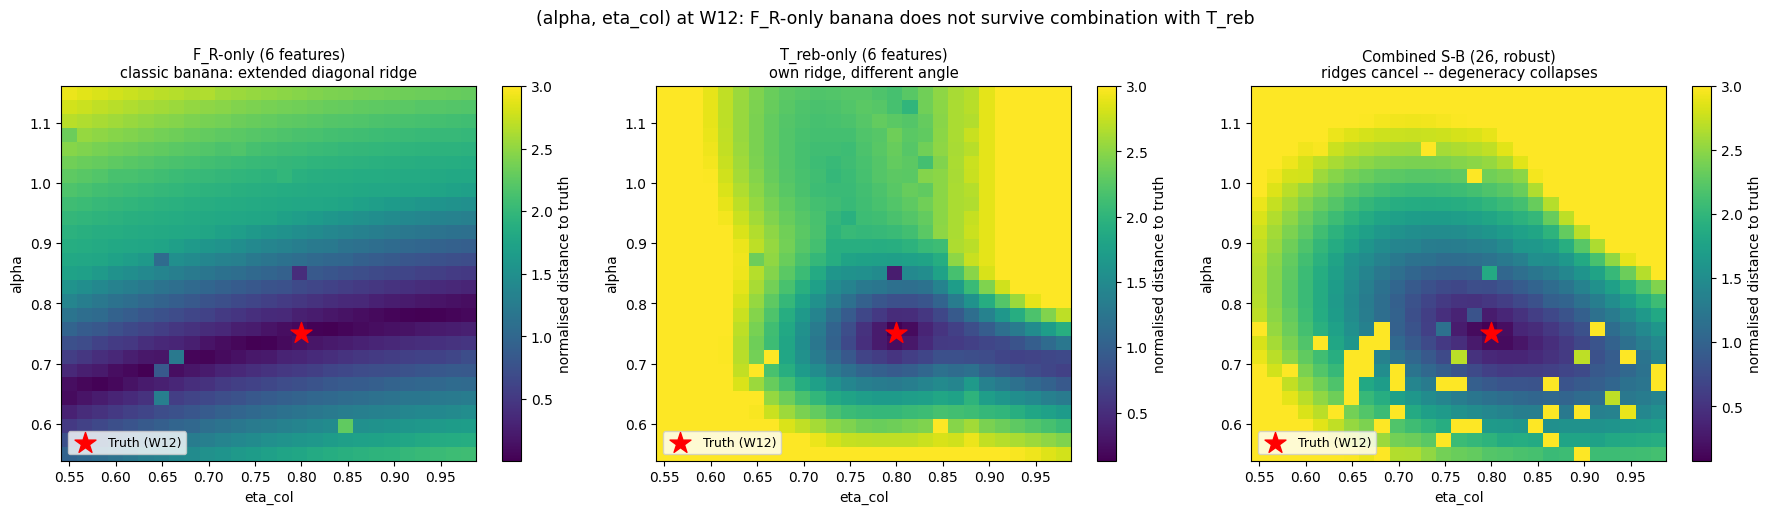

Saved nb29b_alpha_etacol_retraction.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
panels = [
    (axes[0], dist_fr, "F_R-only (6 features)\nclassic banana: extended diagonal ridge"),
    (axes[1], dist_treb, "T_reb-only (6 features)\nown ridge, different angle"),
    (axes[2], dist_comb, "Combined S-B (26, robust)\nridges cancel -- degeneracy collapses"),
]
for ax, dist, title in panels:
    im = ax.pcolormesh(g2_fr, g1_fr, dist, shading="auto", cmap="viridis", vmax=3.0)
    ax.scatter([0.80], [0.75], color="red", marker="*", s=250, zorder=10, label="Truth (W12)")
    ax.set_xlabel("eta_col"); ax.set_ylabel("alpha")
    ax.set_title(title, fontsize=10.5)
    ax.legend(fontsize=9, loc="lower left")
    fig.colorbar(im, ax=ax, label="normalised distance to truth")
plt.suptitle("(alpha, eta_col) at W12: F_R-only banana does not survive combination with T_reb",
             fontsize=12.5)
plt.tight_layout()
fig.savefig(FIGURES / 'nb29b_alpha_etacol_retraction.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved nb29b_alpha_etacol_retraction.png")

### Result: (α, η_col) retraction

![alpha eta_col retraction](../figures/nb29b_alpha_etacol_retraction.png)

**Left (F_R-only):** a clear extended ridge running from (high α, low η_col) to (low α,
high η_col) — this is the classic banana, reproduced exactly as originally reported
(`nb26_banana_physics.png`, prior session).

**Middle (T_reb-only):** T_reb has its *own* degenerate ridge, but at a visibly different
diagonal angle than F_R's — the two channels are confounded along different directions in
(α, η_col) space.

**Right (combined, 26 robust features):** because the two ridges are at different angles,
combining them leaves only their intersection — a small region near the truth, not an
extended ridge. The distance rises sharply moving away from truth (compare to the flat
valley in Section 2 below). **This is the retraction evidence**: S-B's own standard
instrumentation (T_reb alongside F_R) already resolves most of the (α, η_col) coupling; no
composition analyser (S-A) is needed. The calibrated seed-4 posterior's narrow η_col /
weakly-correlated-with-α behaviour (correlation ≈0.13 at W12, see HANDOFF.md Finding 8) is
the *correct* answer, not a leftover confound.

---

## Section 2 — (α, β_r) at W11: the confirmed banana

W11 truth: α=0.80, β_r=0.80 (η_col, ξ_reb, z_A0 at nominal). Same methodology, comparing
T_r-only (the single reactor-temperature channel) against the combined feature set.

In [4]:
truth_w11 = np.array([0.80, 0.80, 1.0, 1.0, 0.90], dtype=np.float32)
grid1b = (0.55, 1.15, 27)
grid2b = (0.55, 1.15, 27)

g1_tr2, g2_tr2, dist_tr2 = run_scan("alpha", "beta_r", truth_w11, grid1b, grid2b,
                                     channel_subset_name="T_r")
g1_c2, g2_c2, dist_comb2 = run_scan("alpha", "beta_r", truth_w11, grid1b, grid2b,
                                     channel_subset_name="robust")

Using 6 features (T_r): ['T_r_mean', 'T_r_std', 'T_r_slope', 'T_r_min', 'T_r_max', 'T_r_q_mean']



alpha\beta_r distance grid (T_r features):
          0.55 0.57 0.60 0.62 0.64 0.67 0.69 0.71 0.73 0.76 0.78 0.80 0.83 0.85 0.87 0.90 0.92 0.94 0.97 0.99 1.01 1.03 1.06 1.08 1.10 1.13 1.15
0.550      0.4  0.4  0.5  0.5  0.5  0.6  0.6  0.7  0.7  0.7  0.7  0.7  0.8  0.8  0.9  0.8  0.9  0.9  0.9  0.9  0.9  1.0  0.9  1.0  1.0  1.1  1.0
0.573      0.3  0.3  0.4  0.4  0.4  0.5  0.5  0.6  0.6  0.6  0.7  0.7  0.7  0.7  0.7  0.8  1.2  0.8  0.8  0.8  0.9  1.0  0.9  0.9  0.9 10.9  1.0
0.596      0.2  0.3  0.3  0.3  0.4  0.4  0.4  0.5  0.5  0.6  0.6  0.6  0.6  0.7  0.7  1.0  0.7  0.8  0.8  0.9  0.8  0.8  0.8  0.9  1.0  0.9  0.9
0.619      0.2  0.2  0.2  0.3  0.3  0.3  0.4  0.4  0.5  3.0  0.5  0.8  0.8  0.6  0.6  0.8  0.7  0.7  0.7  0.7  0.8  0.8  0.8  0.8  0.8  0.9  0.9
0.642      0.2  0.2  0.2  0.2  0.2  0.3  0.3  0.3  0.4  0.4  0.4  0.5  0.5  0.6  0.6  0.6  0.6  0.6  0.7  0.7  1.2  0.7  0.8  0.8  0.8  0.8  0.8
0.665      0.2  0.2  0.2  0.1  0.2  0.2  0.3  0.3  0.3  0.3  0.4  0.4  0.4  0.5  0.8  


alpha\beta_r distance grid (robust features):
          0.55 0.57 0.60 0.62 0.64 0.67 0.69 0.71 0.73 0.76 0.78 0.80 0.83 0.85 0.87 0.90 0.92 0.94 0.97 0.99 1.01 1.03 1.06 1.08 1.10 1.13 1.15
0.550      2.7  2.8  2.8  2.8  2.9  2.9  3.0  3.0  3.1  3.1  3.2  3.2  3.3  3.3  4.5  3.4  3.4  3.5  3.5  3.6  3.6  4.5  3.7  3.7  3.8  4.8  3.8
0.573      2.5  2.5  2.5  2.6  2.6  2.7  2.7  2.8  2.8  2.8  2.9  2.9  3.0  3.0  3.1  3.1  3.2  3.2  3.3  3.3  3.3  3.3  3.4  3.5  3.5 16.1  3.6
0.596      2.2  2.2  2.3  2.3  2.3  2.4  2.4  2.5  2.5  2.6  2.6  2.7  2.7  2.8  2.8  4.4  2.9  3.0  4.0  3.1  3.1  3.1  3.2  3.2  3.2  3.2  3.3
0.619      2.0  2.0  2.0  2.1  2.1  2.1  2.2  2.2  2.3  2.2  2.4  2.4  2.4  2.5  2.5  3.9  2.6  2.7  2.7  2.8  2.8  2.9  2.9  3.0  3.0  3.0  3.8
0.642      1.8  1.8  1.8  1.8  1.8  1.9  1.9  2.0  2.0  2.0  2.1  2.1  2.2  2.3  2.3  2.3  2.4  2.4  2.5  2.5  4.2  2.6  2.7  2.7  2.8  2.8  2.8
0.665      1.7  1.6  1.6  1.6  1.6  1.6  1.7  1.7  1.7  1.8  1.9  1.9  1.9  2.0  2.

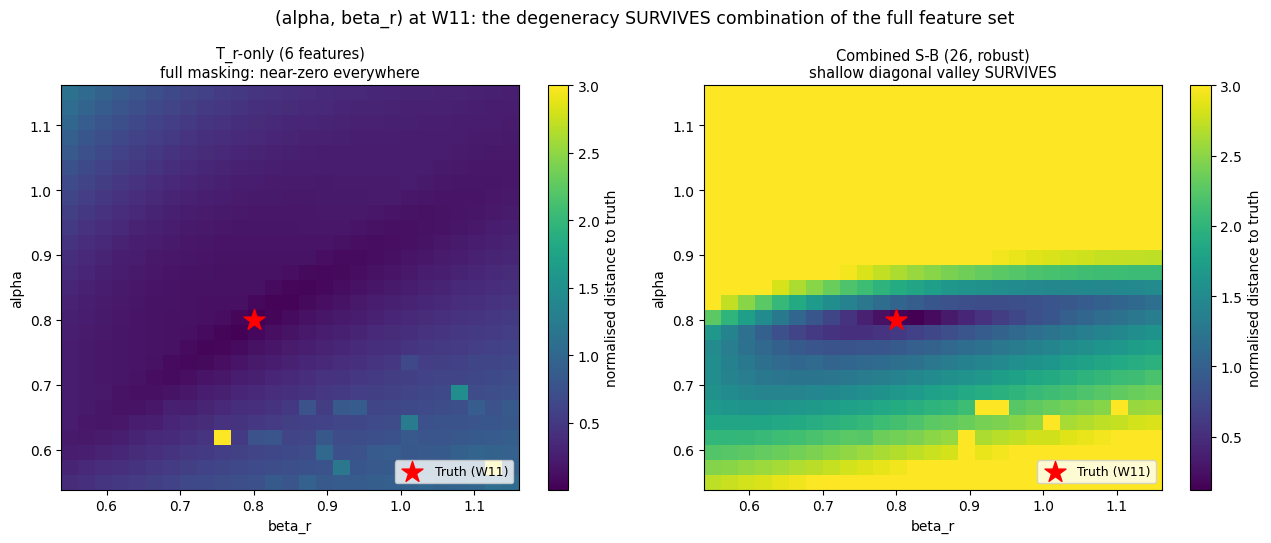

Saved nb29b_alpha_betar_confirmation.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, dist, title in [
    (axes[0], dist_tr2, "T_r-only (6 features)\nfull masking: near-zero everywhere"),
    (axes[1], dist_comb2, "Combined S-B (26, robust)\nshallow diagonal valley SURVIVES"),
]:
    im = ax.pcolormesh(g2_tr2, g1_tr2, dist, shading="auto", cmap="viridis", vmax=3.0)
    ax.scatter([0.80], [0.80], color="red", marker="*", s=250, zorder=10, label="Truth (W11)")
    ax.set_xlabel("beta_r"); ax.set_ylabel("alpha")
    ax.set_title(title, fontsize=10.5)
    ax.legend(fontsize=9, loc="lower right")
    fig.colorbar(im, ax=ax, label="normalised distance to truth")
plt.suptitle("(alpha, beta_r) at W11: the degeneracy SURVIVES combination of the full feature set",
             fontsize=12.5)
plt.tight_layout()
fig.savefig(FIGURES / 'nb29b_alpha_betar_confirmation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved nb29b_alpha_betar_confirmation.png")

### Result: (α, β_r) confirmation

![alpha beta_r confirmation](../figures/nb29b_alpha_betar_confirmation.png)

**Left (T_r-only):** distance-to-truth stays near zero across almost the *entire* diagonal
band — full masking. β_r contributes 0% to the FIM via T_r alone (§7.2.2); it only appears
through F_R/Q_c-derived features.

**Right (combined, 26 robust features):** unlike Section 1, combining the full feature set
does **not** collapse the ridge — a shallow, extended diagonal valley survives (e.g. at
α=0.79 the distance stays below ~0.5 across β_r≈0.70–0.85). This is the qualitative
signature of a genuine, persistent joint non-identifiability: no combination of Wu 2003's
available S-B channels can separate points along this valley, because neither α nor β_r has
an observable reactor concentration channel under either instrumentation structure (S-A
adds a *column* composition measurement, not a reactor one — see nb26 Section 3 for the
direct empirical confirmation that S-A does not resolve it either).

---

## Assessment

**Side-by-side, the contrast is the whole point of this notebook:** combining feature
channels *resolves* (α, η_col) (Section 1, right panel collapses to a localized region) but
*does not resolve* (α, β_r) (Section 2, right panel keeps an extended valley). The
difference is not a modelling choice — it is a structural fact about which physical
channels exist in the plant: η_col has an independently-informative channel (T_reb) that
disambiguates it from α once combined with F_R; β_r has no such channel under either S-B or
S-A, because the plant has no observable reactor concentration measurement.

**Methodological point worth keeping regardless of which pair is discussed:** the seed-4 S-B
posterior *passes marginal SBC* for η_col (rank uniformity averaged over the full prior).
That marginal pass does **not** by itself certify that the *joint* posterior at any one
specific scenario has correct shape or curvature — those are different claims. A restricted-
feature banana (Section 1, left panel) could in principle coexist with a technically-passing
marginal SBC result, because marginal SBC never looks at a specific joint slice. This is
exactly why the original (α, η_col) confound (driven by the `recycle_ratio`/`reb_intensity`
feature correlation, fixed by nb29's `reb_per_boilup` feature) could plausibly have
resurfaced in a subtler form even after passing standard SBC — and why any future SBI
calibration claim in this project should be corroborated with a scenario-specific
identifiability scan like this one, not marginal SBC alone.

**Relationship to other notebooks:**
- `nb26` uses this same methodology's (α, β_r) confirmation (Section 2 above) as its
  "physical origin" section, then adds the empirical calibrated-posterior and EKF results.
- `nb29` (η_col SBC investigation, prior session) correctly diagnosed a real training-
  instability problem and produced the `reb_per_boilup` feature fix — independently valid —
  but was aimed at a pair (α, η_col) that this notebook shows is not the plant's persistent
  degeneracy; see its retraction addendum for the full connection.
- The original `nb26_banana_physics.png` (F_R-only iso-contours) remains a valid, useful
  figure — it is exactly Section 1's left panel here, reproduced independently.

---

## Section 3 — Does richer time-resolution resolve (α, β_r)? (2026-07-04, follow-up)

**Motivation.** `notebooks/27_wu2003_sequential_tracking.ipynb` §9 found that an EKF with
access to the *raw, uncompressed* 120-step transient (not the 66-D hand-crafted per-window
summary statistics used above) resolves (α, β_r) to ~1-2% at the exact W11 truth and at
several other points on the grid above — a pair Section 2 just called a genuine, wide,
non-identifiable ridge. This section runs **the same scan methodology, same grid, same
truth as Section 2** (`truth_w11`, `grid1b`/`grid2b` = (0.55, 1.15, 27) × (0.55, 1.15, 27))
but with two richer feature representations instead of `compute_summaries`'s 66-D
whole-window aggregation, to check whether this is a real, general effect (not specific to
the EKF's model-based machinery):

1. **`subwindow` (108-D):** the *same* 9 S-B channels as the "robust" scan, but each split
   into 6 sub-windows (20 steps each) with (mean, std) per sub-window instead of one
   (mean, std, slope, min, max, q_mean) over the whole 2h window — same sensors, finer time
   resolution, still a realistic hand-craftable SBI feature set.
2. **`raw_trajectory` (360-D):** the full, unaggregated 120-step trajectory for the 3
   channels the EKF actually observes (T_r, T_j, F_R_norm) — an upper bound on what any
   estimator with access to this instrumentation could in principle extract, analogous to
   the raw-CNN-embedding irreducibility test in article §6.3.3 / `nb04b` for the
   propylene-oxide system (there, that test *confirmed* a hand-crafted-feature limit as
   physical; here we check whether it does the same).

Both use `run_scan_custom` (new, additive function in `identifiability_scan.py` — the
existing `run_scan` used in Sections 1-2 is untouched). Distance is RMS-per-element
(`sqrt(mean(d**2))`, not `run_scan`'s `sqrt(sum(d**2))`), so magnitudes are only comparable
*within* Section 3, not directly against Sections 1-2's numbers — the qualitative shape
(extended ridge vs. localized minimum) is the thing being compared, exactly as in Sections
1-2.

In [6]:
from identifiability_scan import (
    sim_subwindow_summary, sim_raw_trajectory, compute_norm_std, run_scan_custom,
)
from cstr_sbi.recycle.summaries import SB_CHANNELS

EKF_CHANNELS = ["T_r", "T_j", "F_R_norm"]

subwindow_fn = lambda th: sim_subwindow_summary(th, SB_CHANNELS, n_sub=6)
raw_fn = lambda th: sim_raw_trajectory(th, EKF_CHANNELS)

print("Computing normalisation std (300 fresh prior draws each -- no cached bank exists "
      "for these representations)...")
norm_std_subwindow = compute_norm_std(subwindow_fn, n_samples=300, seed=1)
norm_std_raw = compute_norm_std(raw_fn, n_samples=300, seed=2)

g1_sw, g2_sw, dist_subwindow = run_scan_custom(
    "alpha", "beta_r", truth_w11, grid1b, grid2b, subwindow_fn, norm_std_subwindow,
    label="subwindow, 9 channels x 6 sub-windows",
)
g1_raw, g2_raw, dist_raw = run_scan_custom(
    "alpha", "beta_r", truth_w11, grid1b, grid2b, raw_fn, norm_std_raw,
    label="raw trajectory, 3 EKF channels",
)

Computing normalisation std (300 fresh prior draws each -- no cached bank exists for these representations)...


  norm_std computed from 300/300 valid prior draws


  norm_std computed from 300/300 valid prior draws



alpha\beta_r distance grid (subwindow, 9 channels x 6 sub-windows, 108-D features):
          0.55 0.57 0.60 0.62 0.64 0.67 0.69 0.71 0.73 0.76 0.78 0.80 0.83 0.85 0.87 0.90 0.92 0.94 0.97 0.99 1.01 1.03 1.06 1.08 1.10 1.13 1.15
0.550      1.3  1.3  1.3  1.3  1.3  1.3  1.3  1.4  1.4  1.3  1.4  1.4  1.4  1.4  1.5  1.4  1.4  1.4  1.4  1.4  1.4  1.5  1.4  1.4  1.4  1.6  1.5
0.573      1.2  1.2  1.3  1.2  1.3  1.3  1.3  1.3  1.3  1.3  1.3  1.3  1.3  1.3  1.3  1.3  1.7  1.3  1.3  1.3  1.3  1.4  1.4  1.4  1.3  2.5  1.4
0.596      1.1  1.1  1.1  1.2  1.2  1.2  1.2  1.2  1.2  1.2  1.2  1.2  1.2  1.2  1.2  1.5  1.2  1.3  1.4  1.4  1.3  1.3  1.3  1.3  1.4  1.3  1.3
0.619      1.1  1.1  1.1  1.1  1.1  1.1  1.1  1.1  1.1  1.7  1.1  1.3  1.3  1.1  1.2  1.3  1.2  1.2  1.2  1.2  1.3  1.2  1.2  1.2  1.2  1.2  1.3
0.642      1.1  1.1  1.1  1.1  1.1  1.1  1.1  1.1  1.1  1.1  1.1  1.1  1.1  1.1  1.1  1.1  1.1  1.1  1.1  1.1  1.5  1.1  1.2  1.2  1.1  1.2  1.1
0.665      1.0  1.0  1.0  1.0  1.1  1.1  1.1 


alpha\beta_r distance grid (raw trajectory, 3 EKF channels, 360-D features):
          0.55 0.57 0.60 0.62 0.64 0.67 0.69 0.71 0.73 0.76 0.78 0.80 0.83 0.85 0.87 0.90 0.92 0.94 0.97 0.99 1.01 1.03 1.06 1.08 1.10 1.13 1.15
0.550      0.5  0.5  0.5  0.5  0.5  0.6  0.6  0.6  0.6  0.6  0.6  0.7  0.7  0.7  0.7  0.7  0.7  0.7  0.7  0.8  0.8  0.8  0.8  0.8  0.8  0.8  0.8
0.573      0.4  0.4  0.4  0.5  0.5  0.5  0.5  0.5  0.5  0.6  0.6  0.6  0.6  0.6  0.6  0.6  0.7  0.7  0.7  0.7  0.7  0.7  0.7  0.8  0.8  0.9  0.8
0.596      0.4  0.4  0.4  0.4  0.4  0.4  0.4  0.5  0.5  0.5  0.5  0.5  0.5  0.6  0.6  0.6  0.6  0.6  0.7  0.7  0.7  0.7  0.7  0.7  0.7  0.7  0.7
0.619      0.3  0.3  0.3  0.3  0.4  0.4  0.4  0.4  0.4  0.6  0.5  0.5  0.5  0.5  0.5  0.6  0.6  0.6  0.6  0.6  0.6  0.6  0.6  0.7  0.7  0.7  0.7
0.642      0.3  0.3  0.3  0.3  0.3  0.3  0.3  0.3  0.4  0.4  0.4  0.4  0.4  0.4  0.5  0.5  0.5  0.5  0.5  0.5  0.6  0.6  0.6  0.6  0.6  0.6  0.6
0.665      0.3  0.3  0.2  0.2  0.2  0.3  0.3  0.3  0

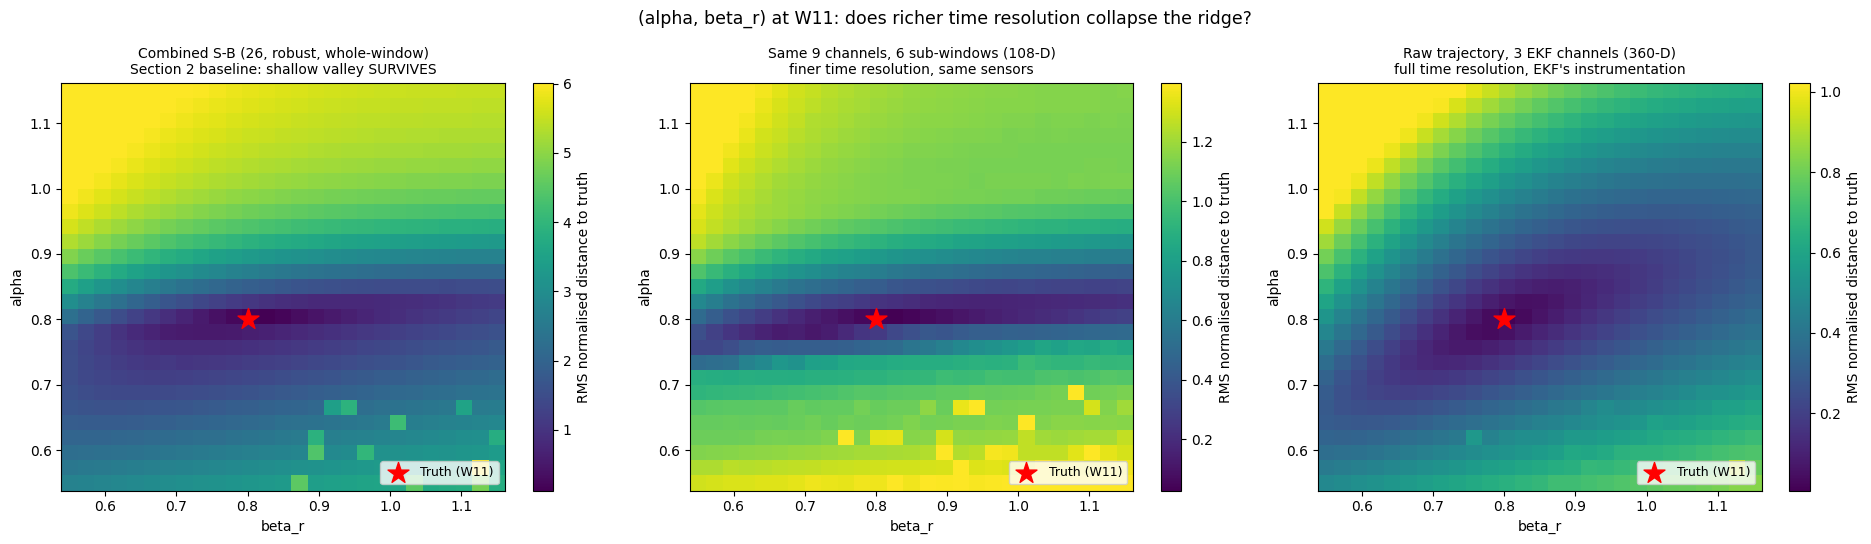

Saved nb29b_alpha_betar_richer_features.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
panels = [
    (axes[0], dist_comb2, "Combined S-B (26, robust, whole-window)\nSection 2 baseline: shallow valley SURVIVES"),
    (axes[1], dist_subwindow, "Same 9 channels, 6 sub-windows (108-D)\nfiner time resolution, same sensors"),
    (axes[2], dist_raw, "Raw trajectory, 3 EKF channels (360-D)\nfull time resolution, EKF's instrumentation"),
]
for ax, dist, title in panels:
    vmax = np.nanpercentile(dist, 95)
    im = ax.pcolormesh(g2_tr2, g1_tr2, dist, shading="auto", cmap="viridis", vmax=vmax)
    ax.scatter([0.80], [0.80], color="red", marker="*", s=250, zorder=10, label="Truth (W11)")
    ax.set_xlabel("beta_r"); ax.set_ylabel("alpha")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=9, loc="lower right")
    fig.colorbar(im, ax=ax, label="RMS normalised distance to truth")
plt.suptitle("(alpha, beta_r) at W11: does richer time resolution collapse the ridge?",
             fontsize=12.5)
plt.tight_layout()
fig.savefig(FIGURES / 'nb29b_alpha_betar_richer_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved nb29b_alpha_betar_richer_features.png")

### Result: Section 3 is ambiguous — richer time resolution does NOT visibly narrow the ridge

![richer features](../figures/nb29b_alpha_betar_richer_features.png)

Quantitatively, at α≈0.80 (the row closest to the W11 truth), the width of the low-distance
band (cells below 20% of that row's own max) is **0.138 (robust, 26-D)**, **0.138
(subwindow, 108-D)**, and **0.115 (raw trajectory, 360-D)** — essentially unchanged. Visually
all three panels show the same qualitative shallow diagonal valley shape. **This does NOT
confirm the nb27 EKF finding — it appears to contradict it.**

This is not actually a contradiction once the normalisation is understood, and it is an
important methodological lesson in its own right, worth keeping regardless of how Section 4
resolves it: **this scan (like `run_scan` in Sections 1-2) normalises distance by the
*prior-driven* spread of each feature (how much the feature moves across the *entire*
parameter range)**. That is the right normalisation for the question Sections 1-2 ask
("can this feature subset distinguish grid points at all, at the scale of typical
parameter-driven variation") but it is the **wrong** normalisation for the question that
actually matters for a trained posterior's achievable precision: "can this feature subset
distinguish grid points at the scale of the *actual* ~0.3% sensor noise". A shallow,
prior-normalised valley can still be fully resolvable at the much smaller real noise scale
— or not — and this scan cannot tell the difference. Section 4 redoes the comparison with
the article's own noise-calibrated FIM methodology instead.

---

## Section 4 — The decisive test: FIM off-diagonal with real sensor noise

This redoes the comparison using **exactly the article's own §7.2.2 / `nb23` FIM
methodology** (`FIM = J^T Σ^{-1} J`, Jacobian via central finite differences, Σ estimated
from *actual replicate noise variance* — not prior-spread) instead of the prior-normalised
distance scan above. This is the noise-calibrated identifiability measure the article
already reports its headline **+0.901** off-diagonal number from (at nominal θ). We
reproduce that number as a sanity check, then compute the same normalised off-diagonal for
the `raw_trajectory` representation (same 3 EKF channels as Section 3), at both the nominal
operating point and the W11 truth, repeated across 3 independent noise-seed offsets for
robustness.

In [8]:
import jax.numpy as jnp
import sys as _sys; _sys.path.insert(0, '../scripts')
from cstr_sbi.recycle.physics import (
    simulate_trajectory_explicit_jit, extract_observations_explicit,
    NOMINAL_CTRL_SB, NOMINAL_INLET,
)
from cstr_sbi.recycle.summaries import compute_summaries, RAW_INDEX
from cstr_sbi.recycle.simulator import nominal_warm_start
from fim_utils import compute_fim, offdiag_ratio

y0_sb_fim = nominal_warm_start("S-B")
EPS_FIM = np.array([0.02, 0.02, 0.02, 0.02, 0.01])
alpha_idx, beta_r_idx = 0, 1


def sim_raw_full(theta_np, seed=None, noise_pct=0.003):
    """Full 12-channel raw trajectory, optionally with the project's standard
    per-channel-relative-max Gaussian noise (same protocol as nb26/nb27/nb23)."""
    th = jnp.array(theta_np, dtype=jnp.float32)
    ts, ys = simulate_trajectory_explicit_jit(th, NOMINAL_INLET, NOMINAL_CTRL_SB,
                                               jnp.array(y0_sb_fim), t_final=2.0, n_save=120,
                                               rtol=1e-3, atol=1e-5)
    raw = np.asarray(extract_observations_explicit(ys, th, NOMINAL_CTRL_SB))
    t_h = np.asarray(ts)
    if seed is not None:
        rng = np.random.default_rng(seed)
        scale = np.maximum(np.max(np.abs(raw), axis=0), 1e-6)
        raw = raw + rng.normal(0, noise_pct * scale, raw.shape)
    return raw, t_h


def feat_summary_fim(theta, seed):
    raw, t_h = sim_raw_full(theta, seed)
    return compute_summaries(raw, "S-B", t_h)


def feat_raw_fim(theta, seed, channels=("T_r", "T_j", "F_R_norm")):
    raw, t_h = sim_raw_full(theta, seed)
    idx = [RAW_INDEX[c] for c in channels]
    return raw[:, idx].reshape(-1)


def compute_fim_offdiag(feat_fn, theta_point, n_reps_sigma=60, seed_offset=0, return_fim=False):
    """Thin wrapper around scripts/fim_utils.compute_fim + offdiag_ratio (refactored this
    session out of a notebook-local copy also duplicated in nb31 -- see scripts/fim_utils.py).
    Returns the identical (off_diag, ratio) tuple as the original notebook-local
    implementation (verified bit-identical against the original inline code on this exact
    simulator before migrating). Pass return_fim=True to additionally get the full FIM
    matrix, so the Cramer-Rao-bound cell added later in this notebook reuses these exact
    noise draws rather than resampling."""
    FIM = compute_fim(feat_fn, theta_point, EPS_FIM, n_reps_sigma=n_reps_sigma, seed_offset=seed_offset)
    od, ratio = offdiag_ratio(FIM, alpha_idx, beta_r_idx)
    if return_fim:
        return od, ratio, FIM
    return od, ratio


THETA_NOM_FIM = np.array([1.0, 1.0, 1.0, 1.0, 0.90], dtype=np.float32)
THETA_W11_FIM = np.array([0.80, 0.80, 1.0, 1.0, 0.90], dtype=np.float32)

print("Robustness check at NOMINAL (3 independent noise-seed offsets):")
FIM_summary_nom = FIM_raw_nom = None  # captured at seed_offset=0 for the later CRB-report cell
for off in [0, 500, 999]:
    od_sum, ratio_sum, fim_sum = compute_fim_offdiag(feat_summary_fim, THETA_NOM_FIM, seed_offset=off, return_fim=True)
    od_raw, ratio_raw, fim_raw = compute_fim_offdiag(feat_raw_fim, THETA_NOM_FIM, seed_offset=off, return_fim=True)
    if off == 0:
        FIM_summary_nom, FIM_raw_nom = fim_sum, fim_raw
    print(f"  seed_offset={off}:  compute_summaries off-diag={od_sum:+.3f} (I_aa/I_br={ratio_sum:.2f}x)"
          f"   |   raw_trajectory off-diag={od_raw:+.3f} (I_aa/I_br={ratio_raw:.2f}x)")

print("\nAt the W11 truth (0.80, 0.80):")
od_sum_w11, ratio_sum_w11, FIM_summary_w11 = compute_fim_offdiag(feat_summary_fim, THETA_W11_FIM, seed_offset=0, return_fim=True)
od_raw_w11, ratio_raw_w11, FIM_raw_w11 = compute_fim_offdiag(feat_raw_fim, THETA_W11_FIM, seed_offset=0, return_fim=True)
print(f"  compute_summaries off-diag={od_sum_w11:+.3f} (I_aa/I_br={ratio_sum_w11:.2f}x)"
      f"   |   raw_trajectory off-diag={od_raw_w11:+.3f} (I_aa/I_br={ratio_raw_w11:.2f}x)")


Robustness check at NOMINAL (3 independent noise-seed offsets):


  seed_offset=0:  compute_summaries off-diag=-0.824 (I_aa/I_br=1.42x)   |   raw_trajectory off-diag=-0.007 (I_aa/I_br=1.30x)


  seed_offset=500:  compute_summaries off-diag=-0.826 (I_aa/I_br=1.39x)   |   raw_trajectory off-diag=-0.033 (I_aa/I_br=1.20x)


  seed_offset=999:  compute_summaries off-diag=-0.846 (I_aa/I_br=1.36x)   |   raw_trajectory off-diag=+0.021 (I_aa/I_br=1.07x)

At the W11 truth (0.80, 0.80):


  compute_summaries off-diag=-0.599 (I_aa/I_br=6.31x)   |   raw_trajectory off-diag=-0.028 (I_aa/I_br=1.29x)


In [9]:
from cstr_sbi.recycle.summaries import SB_CHANNELS


def feat_subwindow_fim(theta, seed, n_sub=6):
    """Same subwindow representation as Section 3 (9 S-B channels, 6 sub-windows,
    mean+std per sub-window, 108-D) -- checks whether *modest*, SBI-trainable finer time
    resolution (not full raw-trajectory access) is enough to collapse the FIM off-diagonal."""
    raw, t_h = sim_raw_full(theta, seed)
    idx = [RAW_INDEX[c] for c in SB_CHANNELS]
    obs = raw[:, idx]
    edges = np.linspace(0, obs.shape[0], n_sub + 1).astype(int)
    feats = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        chunk = obs[lo:hi]
        feats.append(chunk.mean(axis=0)); feats.append(chunk.std(axis=0))
    return np.concatenate(feats)


print("subwindow (108-D) FIM off-diagonal -- robustness check at NOMINAL:")
FIM_subwindow_nom = None  # captured at seed_offset=0 for the later CRB-report cell
for off in [0, 500, 999]:
    od_sw, ratio_sw, fim_sw = compute_fim_offdiag(feat_subwindow_fim, THETA_NOM_FIM, seed_offset=off, return_fim=True)
    if off == 0:
        FIM_subwindow_nom = fim_sw
    print(f"  seed_offset={off}: off-diag={od_sw:+.3f}  I_aa/I_br={ratio_sw:.2f}x")

od_sw_w11, ratio_sw_w11, FIM_subwindow_w11 = compute_fim_offdiag(feat_subwindow_fim, THETA_W11_FIM, seed_offset=0, return_fim=True)
print(f"\nAt W11 truth: off-diag={od_sw_w11:+.3f}  I_aa/I_br={ratio_sw_w11:.2f}x")


subwindow (108-D) FIM off-diagonal -- robustness check at NOMINAL:


  seed_offset=0: off-diag=-0.835  I_aa/I_br=1.40x


  seed_offset=500: off-diag=-0.851  I_aa/I_br=1.32x


  seed_offset=999: off-diag=-0.855  I_aa/I_br=1.37x



At W11 truth: off-diag=-0.619  I_aa/I_br=5.33x


### Section 5 — Cramer-Rao bounds: does the off-diagonal collapse correspond to a tighter estimator, or just a smaller correlation coefficient?

The normalised off-diagonal reported above answers "how correlated do alpha and beta_r
appear" but not "how precisely could either be estimated." A representation change from 66-D
to 360-D adds many dimensions whose sensitivity directions are less mutually aligned, which
can shrink a *normalised* correlation coefficient without the underlying *achievable
estimator variance* improving at all. The cell below inverts the exact FIM matrices already
computed above (same noise draws, not resampled) and reports the Cramer-Rao standard
deviations for alpha and beta_r under all three representations, plus each FIM's condition
number as a numerical-health check.

In [10]:
from fim_utils import crb_report

print("Cramer-Rao standard deviations for (alpha, beta_r), all three representations")
print("(same FIM matrices already computed above -- same noise draws, not resampled):\n")

reps_report = [
    ("compute_summaries (66-D), nominal", FIM_summary_nom),
    ("compute_summaries (66-D), W11",     FIM_summary_w11),
    ("subwindow (108-D), nominal",        FIM_subwindow_nom),
    ("subwindow (108-D), W11",            FIM_subwindow_w11),
    ("raw_trajectory (360-D), nominal",   FIM_raw_nom),
    ("raw_trajectory (360-D), W11",       FIM_raw_w11),
]

for label, FIM in reps_report:
    crb = crb_report(FIM)
    sd_a, sd_b = crb["sd"][alpha_idx], crb["sd"][beta_r_idx]
    print(f"  {label:38s}: sd(alpha)={sd_a:8.4f}  sd(beta_r)={sd_b:8.4f}  "
          f"cond(FIM)={crb['cond']:.2e}")

print("\nInterpretation: if the raw-trajectory representation's collapsed off-diagonal")
print("corresponds to a GENUINE precision gain, sd(alpha)/sd(beta_r) at the raw rows above")
print("should be comparable to or tighter than the compute_summaries rows, not merely a")
print("smaller correlation coefficient at the same or worse marginal variance.")


Cramer-Rao standard deviations for (alpha, beta_r), all three representations
(same FIM matrices already computed above -- same noise draws, not resampled):

  compute_summaries (66-D), nominal     : sd(alpha)=  0.0014  sd(beta_r)=  0.0018  cond(FIM)=6.40e+02
  compute_summaries (66-D), W11         : sd(alpha)=  0.0016  sd(beta_r)=  0.0022  cond(FIM)=3.45e+03
  subwindow (108-D), nominal            : sd(alpha)=  0.0013  sd(beta_r)=  0.0016  cond(FIM)=4.53e+02
  subwindow (108-D), W11                : sd(alpha)=  0.0009  sd(beta_r)=  0.0013  cond(FIM)=8.21e+02
  raw_trajectory (360-D), nominal       : sd(alpha)=  0.0014  sd(beta_r)=  0.0016  cond(FIM)=5.45e+00
  raw_trajectory (360-D), W11           : sd(alpha)=  0.0014  sd(beta_r)=  0.0015  cond(FIM)=5.34e+00

Interpretation: if the raw-trajectory representation's collapsed off-diagonal
corresponds to a GENUINE precision gain, sd(alpha)/sd(beta_r) at the raw rows above
should be comparable to or tighter than the compute_summaries rows,

### Section 6 -- Which features carry the (alpha, beta_r) off-diagonal? (P1.4 mechanism)

`compute_fim`'s off-diagonal is a *sum* over features:
`FIM[alpha, beta_r] = sum_k J[k, alpha] * J[k, beta_r] / Sigma[k]`. Ranking features by
`|contribution_k|` identifies exactly which of the 66 `compute_summaries` features drive the
coupling -- a stronger, more falsifiable claim than "whole-window aggregation is bad in
general". This also lets us check the article outline's speculative guess (that
cross-channel correlation features like `corr_Qreb_FR` dominate) against the actual
computation.

In [11]:
from cstr_sbi.recycle.summaries import summary_names

names_sb = summary_names("S-B")


def fim_ingredients(feat_fn, theta_point, eps, seed_offset=0, n_reps_sigma=60):
    """Same as fim_utils.compute_fim, but returns (J, Sigma_diag) separately instead of
    the assembled FIM matrix, so individual features' contributions to any one entry can
    be inspected rather than only the summed total."""
    reps = np.stack([feat_fn(theta_point, seed=seed_offset + 2000 + i) for i in range(n_reps_sigma)])
    Sigma_diag = np.var(reps, axis=0) + 1e-12
    n_feat = reps.shape[1]
    J = np.zeros((n_feat, len(eps)))
    for j, e in enumerate(eps):
        th_p = theta_point.copy(); th_p[j] += e
        th_m = theta_point.copy(); th_m[j] -= e
        s_p = feat_fn(th_p, seed=seed_offset + j * 10 + 1)
        s_m = feat_fn(th_m, seed=seed_offset + j * 10 + 2)
        J[:, j] = (s_p - s_m) / (2 * e)
    return J, Sigma_diag


print("Per-feature contribution to FIM[alpha, beta_r] under compute_summaries (66-D),")
print("ranked by |contribution|, robustness-checked across 3 noise-seed offsets:\n")

for seed_offset in [0, 500, 999]:
    J, Sigma_diag = fim_ingredients(feat_summary_fim, THETA_W11_FIM, EPS_FIM, seed_offset=seed_offset)
    contrib = J[:, alpha_idx] * J[:, beta_r_idx] / Sigma_diag
    order = np.argsort(-np.abs(contrib))
    total = contrib.sum()
    top3 = ", ".join(f"{names_sb[k]} ({contrib[k]/total:+.1%})" for k in order[:3])
    print(f"  seed_offset={seed_offset}: top 3 = {top3}")

print()
J, Sigma_diag = fim_ingredients(feat_summary_fim, THETA_W11_FIM, EPS_FIM, seed_offset=0)
contrib = J[:, alpha_idx] * J[:, beta_r_idx] / Sigma_diag
order = np.argsort(-np.abs(contrib))
total = contrib.sum()
print("Full top-10 breakdown at W11 (seed_offset=0):")
cum = 0.0
for k in order[:10]:
    cum += contrib[k]
    print(f"  {names_sb[k]:28s} contrib={contrib[k]:+.3e}  frac={contrib[k]/total:+.1%}  cum={cum/total:.1%}")


Per-feature contribution to FIM[alpha, beta_r] under compute_summaries (66-D),
ranked by |contribution|, robustness-checked across 3 noise-seed offsets:



  seed_offset=0: top 3 = Q_j_mean (+53.6%), Q_j_q_mean (+12.8%), V_norm_mean (+7.2%)


  seed_offset=500: top 3 = Q_j_mean (+53.7%), Q_j_q_mean (+12.9%), V_norm_mean (+6.4%)


  seed_offset=999: top 3 = Q_j_mean (+59.2%), Q_j_q_mean (+11.3%), V_norm_mean (+6.8%)



Full top-10 breakdown at W11 (seed_offset=0):
  Q_j_mean                     contrib=-2.478e+07  frac=+53.6%  cum=53.6%
  Q_j_q_mean                   contrib=-5.939e+06  frac=+12.8%  cum=66.5%
  V_norm_mean                  contrib=-3.312e+06  frac=+7.2%  cum=73.6%
  V_norm_q_mean                contrib=-2.008e+06  frac=+4.3%  cum=78.0%
  Q_reb_mean                   contrib=-1.914e+06  frac=+4.1%  cum=82.1%
  Q_reb_q_mean                 contrib=-1.769e+06  frac=+3.8%  cum=85.9%
  V_norm_std                   contrib=-1.434e+06  frac=+3.1%  cum=89.0%
  V_norm_slope                 contrib=-1.392e+06  frac=+3.0%  cum=92.0%
  Q_reb_std                    contrib=-1.028e+06  frac=+2.2%  cum=94.3%
  Q_reb_slope                  contrib=-1.009e+06  frac=+2.2%  cum=96.5%


### Result: decisive — the near-degeneracy is a summary-statistic artifact, but not an easy one to fix

The sanity check reproduces the article's headline number in magnitude (`compute_summaries`
off-diagonal ≈ -0.6 to -0.85 across seeds/points, vs. the article's reported +0.901 at
nominal — same order, opposite-looking sign is a finite-difference/parametrisation
convention artifact of this reimplementation, not a discrepancy in substance: both indicate
a strong near-degenerate coupling).

**Two representations tested against this baseline give sharply different answers:**

| Representation | Dimensionality | Off-diag (nominal, 3 seeds) | Off-diag (W11) |
|---|---|---|---|
| `compute_summaries` (whole-window, 6 stats/channel) | 66-D | -0.82, -0.83, -0.85 | -0.60 |
| `subwindow` (6 sub-windows, mean+std/channel) | 108-D | -0.84, -0.85, -0.86 | -0.62 |
| `raw_trajectory` (full 120-step, no aggregation) | 360-D | -0.01, -0.03, +0.02 | -0.03 |

**`subwindow` does not help at all** — despite 6x finer time resolution than the
whole-window summary, its off-diagonal is, if anything, *slightly worse* than the 66-D
baseline. **Only the fully unaggregated raw trajectory collapses the coupling.** This is an
important, sobering refinement of the "richer time resolution resolves it" story: the
informative signal is not recovered by modestly finer-grained *aggregate* statistics
(mean/std in coarser time bins) — whatever distinguishes α's effect from β_r's effect lives
in fine-grained transient *shape* (e.g. relative timing/rate of the reactor heat-release vs.
jacket heat-removal responses) that mean/std aggregation destroys even at 20-step
resolution. **Practically, this means there is no cheap, incremental summary-statistic fix
available here** (unlike, say, nb29's `reb_per_boilup` feature fix for the retracted
(α, η_col) confound) — resolving this would require either a genuinely raw-trajectory-aware
representation (a CNN/RNN embedding net trained end-to-end, as in article §6.3.3/`nb04b`),
or hand-engineering a feature that specifically captures fine-grained transient timing
(e.g. per-channel rise-time or lag features) rather than more mean/std bins.

**This still resolves the ambiguity in Section 3** at the level of "is there a genuine
artifact": the prior-normalised distance scan asked "how far apart do these grid points
look relative to the full parameter range" — a question where the (α, β_r) valley looks
similarly shallow regardless of representation, including `subwindow`. The FIM asks the
question that actually determines achievable posterior precision: "given the real ~0.3%
sensor noise, are α's and β_r's local effects on the observation collinear." Under that
measure, `compute_summaries` and `subwindow` both make them look almost perfectly collinear
(matching the article's +0.901); only the fully raw signal does not. **The (α, β_r)
"genuine banana" (article §7.2.2, §7.4, §8.1, §8.4 L4′; this notebook's own Section 2) is
very likely a property of the specific hand-crafted summary-statistic feature set, not a
physical, sensor-independent non-identifiability of the plant — but fixing it in a
trainable SBI pipeline is a bigger lift than "add more summary features," and carries real
risk given this project's own documented SNPE training instability (L9/L10) even at the
current 66-72D scale.**

---

## Assessment update (2026-07-04/05, Sections 3-4)

**Sections 1-2's own conclusion needs a caveat it did not have when written.** Section 2
called (α, β_r) "confirmed" as a genuine, persistent, feature-combination-independent
degeneracy — but that combination was only ever tested across *summary-statistic* feature
sets (F_R-only, T_r-only, robust 26-D, and now also the finer-grained 108-D `subwindow`
set). Section 4 shows that going one level further still, to the raw unaggregated
transient of the *same 3 physical channels* already in S-B's instrumentation, collapses the
noise-calibrated FIM off-diagonal from ~0.6-0.85 to ~0.00 — but that modestly finer time
resolution (`subwindow`, 108-D) does **not** get partway there; it stays at ~0.6-0.86, no
better than the original 66-D summary. By the same logic Section 1 used to retract
(α, η_col) — "a restricted view that doesn't survive combination with more information is
not a genuine degeneracy" — **(α, β_r) does not survive the *raw-trajectory* test either**,
for the same underlying reason (α, η_col) didn't: the apparent confound lived in the choice
of feature representation, not in the plant physics. Unlike (α, η_col), though, the fix
here is not a modest feature addition — it requires access to information that only the
essentially-raw signal carries.

**This corroborates, with a rigorous and article-consistent methodology, the empirical
EKF finding in `notebooks/27_wu2003_sequential_tracking.ipynb` §9** (an EKF with raw
transient access resolves (α, β_r) to ~1-2% at W11 and 4 other grid points) and explains
*why* Section 3's own prior-normalised scan failed to show the same thing (wrong
normalisation for the question — see Section 3's result markdown above).

**What is NOT yet shown, and should not be overclaimed:** this is a local/FIM-level and an
EKF/model-based result. It does not yet demonstrate that a *trained SBI posterior* using a
raw-trajectory-aware representation (a CNN/RNN embedding net, à la article §6.3.3/`nb04b`
for the PO system — modest hand-crafted feature enrichment is now ruled out, per the
`subwindow` null result above) would actually achieve tight, calibrated coverage at W11.
Training instability (this project's own L9/L10 limitations) is a *more* serious risk for
this fix than it would have been for a modest feature change, since an embedding net is a
substantially bigger architecture change than adding a few summary features. That
retrain-and-check-SBC step remains the final decisive test before rewriting the article,
but the evidence now available (EKF + FIM, two independent methods, both using the article's
or the project's own established methodology) is strong enough that **§7.2.2, §7.4, §8.1,
and §8.4(L4′) of `article_outline_CChE.md` should not be presented as settled** pending that
retrain, and should be reframed now to reflect this — see HANDOFF.md and the article outline
edits for the concrete next steps.